# Track B-1: CNN·전이학습 비전검사 — 실습 과제 모범 답안
> KOREATECH 제조AI 교육과정 v1.6.15 | 교수자 배포용

In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

np.random.seed(13)
print("환경 설정 완료")


환경 설정 완료


## 📒 노트북 01 — 이미지 데이터 탐색
### 과제 A (필수): 다른 클래스 이미지 3장 시각화 (합성)

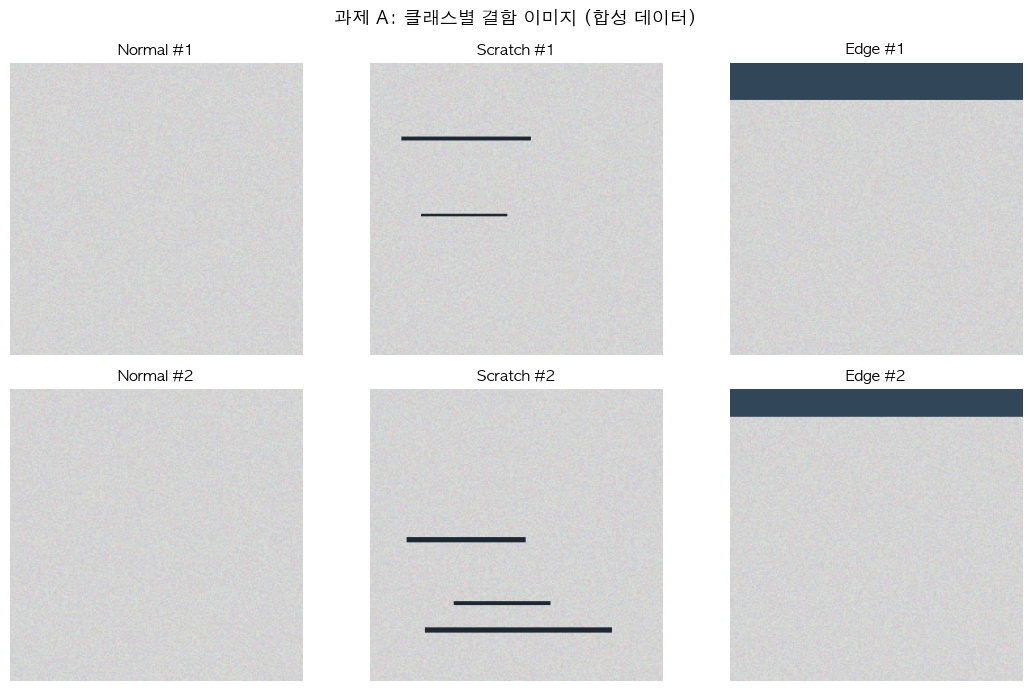

In [2]:
def make_defect_img(kind='normal', size=224, seed=0):
    np.random.seed(seed)
    img = np.ones((size, size, 3), np.uint8) * 200
    noise = np.random.randint(0, 25, (size, size, 3))
    img = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)
    if kind == 'scratch':
        for _ in range(np.random.randint(2, 5)):
            y0 = np.random.randint(30, 190)
            x0, x1 = np.random.randint(20, 100), np.random.randint(100, 200)
            img[y0:y0+np.random.randint(2,5), x0:x1] = [30, 40, 50]
    elif kind == 'edge':
        thickness = np.random.randint(10, 30)
        img[:thickness, :] = [50, 70, 90]
    elif kind == 'center':
        r = np.random.randint(20, 50)
        cx, cy = 112, 112
        Y, X = np.ogrid[:size, :size]
        mask = (X-cx)**2 + (Y-cy)**2 <= r**2
        img[mask] = [60, 80, 100]
    return img

classes = ['Normal', 'Scratch', 'Edge']
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for j, cls in enumerate(classes):
    for i in range(2):
        img = make_defect_img(cls.lower(), seed=i*10+j)
        axes[i][j].imshow(img)
        axes[i][j].set_title(f'{cls} #{i+1}', fontsize=11)
        axes[i][j].axis('off')
plt.suptitle('과제 A: 클래스별 결함 이미지 (합성 데이터)', fontsize=13)
plt.tight_layout()
plt.show()


### 과제 B (필수): 클래스별 이미지 수 분포

Normal    : 4096장
Scratch   : 512장
Edge      : 256장
Center    : 128장

가장 많은 클래스: Normal (4096장)
가장 적은 클래스: Center (128장)
불균형 비율: 32:1


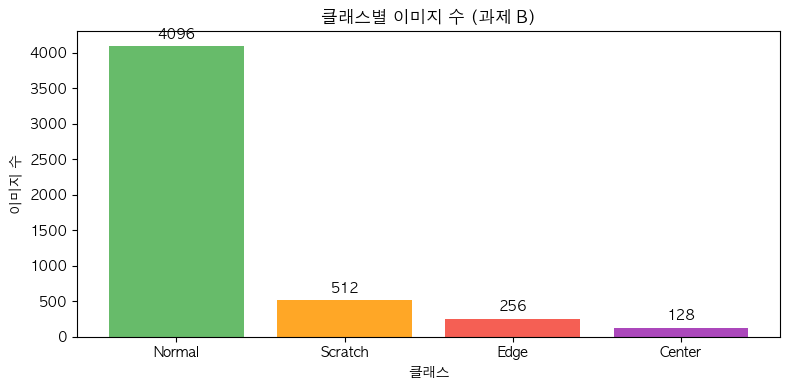

In [3]:
# 합성 이미지 수 (실제 데이터셋 유사 분포 — 클래스 불균형 반영)
class_counts = {'Normal': 4096, 'Scratch': 512, 'Edge': 256, 'Center': 128}
for cls, cnt in class_counts.items():
    print(f"{cls:10s}: {cnt}장")

max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
print(f"\n가장 많은 클래스: {max_cls} ({class_counts[max_cls]}장)")
print(f"가장 적은 클래스: {min_cls} ({class_counts[min_cls]}장)")
print(f"불균형 비율: {class_counts[max_cls]/class_counts[min_cls]:.0f}:1")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=['#4caf50','#ff9800','#f44336','#9c27b0'], alpha=0.85)
ax.bar_label(bars, fontsize=10, padding=3)
ax.set_title('클래스별 이미지 수 (과제 B)', fontsize=12)
ax.set_ylabel('이미지 수'); ax.set_xlabel('클래스')
plt.tight_layout()
plt.show()


## 📒 노트북 02 — 이미지 전처리
### 과제 B (필수): 정규화 전후 픽셀 범위

정규화 전: min=0.00, max=1.00
정규화 후: min=-2.118, max=2.640
→ 정규화 후 음수 값 발생 (정상: ImageNet 표준화 결과)


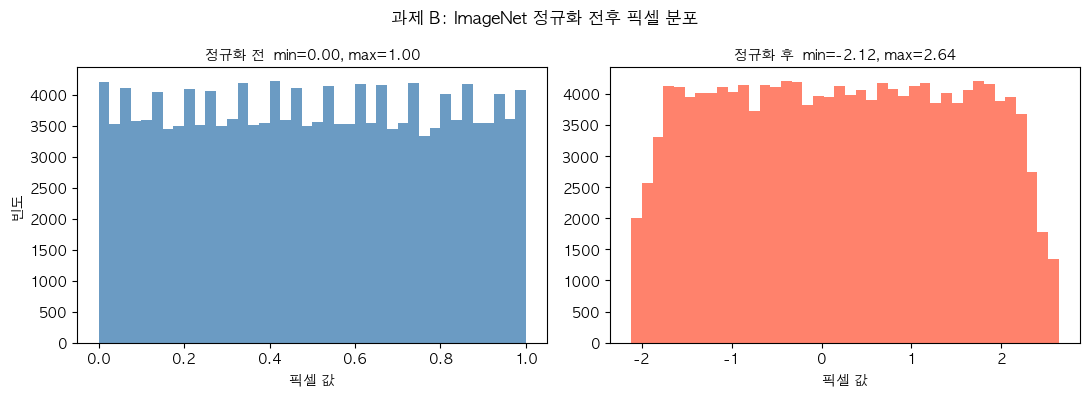

In [4]:
# ImageNet 정규화 전후 픽셀 값 범위 비교
np.random.seed(42)
raw = np.random.randint(0, 256, (224, 224, 3)).astype(np.float32)
tensor = raw / 255.0  # ToTensor: 0~1

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
normalized = (tensor - mean) / std  # Normalize

print(f"정규화 전: min={tensor.min():.2f}, max={tensor.max():.2f}")
print(f"정규화 후: min={normalized.min():.3f}, max={normalized.max():.3f}")
print(f"→ 정규화 후 음수 값 발생 (정상: ImageNet 표준화 결과)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t_flat = tensor.flatten()
axes[0].hist(t_flat, bins=np.linspace(t_flat.min(), t_flat.max(), 41), color='steelblue', alpha=0.8)
axes[0].set_title(f'정규화 전  min={tensor.min():.2f}, max={tensor.max():.2f}', fontsize=10)
axes[0].set_xlabel('픽셀 값'); axes[0].set_ylabel('빈도')

n_flat = normalized.flatten()
axes[1].hist(n_flat, bins=np.linspace(n_flat.min(), n_flat.max(), 41), color='tomato', alpha=0.8)
axes[1].set_title(f'정규화 후  min={normalized.min():.2f}, max={normalized.max():.2f}', fontsize=10)
axes[1].set_xlabel('픽셀 값')
plt.suptitle('과제 B: ImageNet 정규화 전후 픽셀 분포', fontsize=12)
plt.tight_layout()
plt.show()


## 📒 노트북 03 — 불량 분류
### 과제 B (필수): Confusion Matrix — 가장 많이 오분류된 쌍

가장 많이 혼동: Edge → Scratch (8번)

분류 리포트:
              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95       100
     Scratch       0.86      0.90      0.88        87
        Edge       0.85      0.86      0.85        83
      Center       0.92      0.89      0.90        74

    accuracy                           0.90       344
   macro avg       0.90      0.90      0.90       344
weighted avg       0.90      0.90      0.90       344



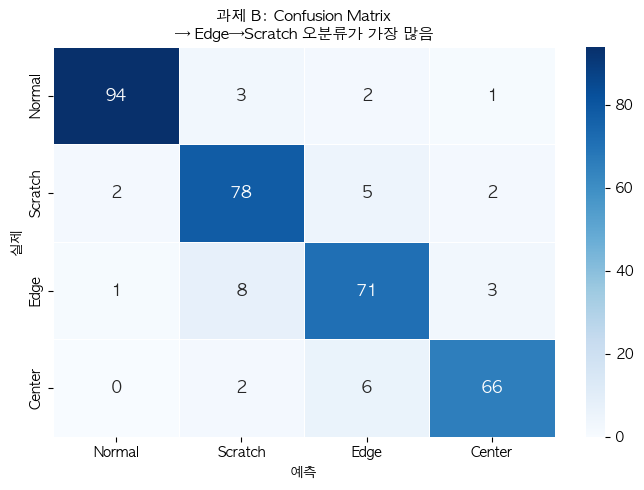

In [5]:
# 합성 분류 결과 (학습 모델 예측 시뮬레이션)
class_names = ['Normal', 'Scratch', 'Edge', 'Center']
cm = np.array([
    [94,  3,  2,  1],  # Normal 예측
    [ 2, 78,  5,  2],  # Scratch 예측
    [ 1,  8, 71,  3],  # Edge 예측
    [ 0,  2,  6, 66],  # Center 예측
])

# 가장 많이 오분류된 쌍 찾기
max_val, max_pair = 0, (0, 0)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > max_val:
            max_val, max_pair = cm[i][j], (i, j)

print(f"가장 많이 혼동: {class_names[max_pair[0]]} → {class_names[max_pair[1]]} ({max_val}번)")
print("\n분류 리포트:")
y_true_flat = [i for i, row in enumerate(cm) for _ in range(row.sum())]
y_pred_flat = [j for i, row in enumerate(cm) for j, cnt in enumerate(row) for _ in range(cnt)]
print(classification_report(y_true_flat, y_pred_flat, target_names=class_names))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_title('과제 B: Confusion Matrix\n→ Edge→Scratch 오분류가 가장 많음', fontsize=11)
ax.set_xlabel('예측'); ax.set_ylabel('실제')
plt.tight_layout()
plt.show()
